In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
import netCDF4 as nc

In [14]:
import xarray as xr
import numpy as np

# ---------------------------
# 1. read GRIDMET data
# ---------------------------
grid_path = "../.data/GRIDMET/gridmet_4km_jja_ne/tmmx_JJA_NE_2000_2025.nc"
ds_grid = xr.open_dataset(grid_path)

print(ds_grid)
print(ds_grid.lat.values[:5], ds_grid.lat.values[-5:])
print(ds_grid.lon.values[:5], ds_grid.lon.values[-5:])

# ---------------------------
# 2. read ETOPO2 topo
# ---------------------------
topo_path = "../.data/ETOPO2/ETOPO2v2c_f4.nc"
ds_topo = xr.open_dataset(topo_path)

# z is the elevation variable
topo = ds_topo["z"]

# rename coordinates to match GRIDMET style
topo = topo.rename({"x": "lon", "y": "lat"})

topo

<xarray.Dataset> Size: 1GB
Dimensions:          (day: 2392, lat: 240, lon: 311, crs: 1)
Coordinates:
  * day              (day) datetime64[ns] 19kB 2000-06-01 ... 2025-08-31
  * lat              (lat) float64 2kB 46.98 46.94 46.9 ... 37.11 37.07 37.03
  * lon              (lon) float64 2kB -79.97 -79.93 -79.89 ... -67.1 -67.06
  * crs              (crs) uint16 2B 3
Data variables:
    air_temperature  (day, lat, lon) float64 1GB ...
[46.98333333 46.94166667 46.9        46.85833333 46.81666667] [37.19166667 37.15       37.10833333 37.06666667 37.025     ]
[-79.97499997 -79.9333333  -79.89166663 -79.84999997 -79.8083333 ] [-67.22499997 -67.1833333  -67.14166663 -67.09999997 -67.0583333 ]


<xarray.DataArray 'z' (lat: 5400, lon: 10800)> Size: 233MB
[58320000 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 22kB -89.98 -89.95 -89.92 ... 89.92 89.95 89.98
  * lon      (lon) float32 43kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Attributes:
    long_name:     z
    actual_range:  [-10791.   8440.]

In [16]:
# ---------------------------
# 3. subset topo to GRIDMET domain
# ---------------------------
lat_min = float(ds_grid.lat.min())
lat_max = float(ds_grid.lat.max())
lon_min = float(ds_grid.lon.min())
lon_max = float(ds_grid.lon.max())

topo_sub = topo.sel(
    lat=slice(lat_min, lat_max),
    lon=slice(lon_min, lon_max)
)

topo_sub

<xarray.DataArray 'z' (lat: 299, lon: 387)> Size: 463kB
[115713 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 1kB 37.05 37.08 37.12 37.15 ... 46.92 46.95 46.98
  * lon      (lon) float32 2kB -79.95 -79.92 -79.88 ... -67.15 -67.12 -67.08
Attributes:
    long_name:     z
    actual_range:  [-10791.   8440.]

In [17]:
# ---------------------------
# 4. regrid topo onto GRIDMET grid
# ---------------------------
topo_on_gridmet = topo_sub.interp(
    lat=ds_grid.lat,
    lon=ds_grid.lon,
    method="linear"
)
topo_on_gridmet

<xarray.DataArray 'z' (lat: 240, lon: 311)> Size: 597kB
array([[           nan,   312.99705388,   326.00050699, ...,
          311.00144899,   361.00299198,            nan],
       [           nan,   337.24916712,   326.25129331, ...,
          272.63081352,   349.75286975,            nan],
       [           nan,   324.99548755,   333.50186242, ...,
          311.75627949,   409.0027746 ,            nan],
       ...,
       [           nan,   370.49763268,   359.00123474, ...,
        -4976.99930574, -4967.99755571,            nan],
       [           nan,   368.50139505,   348.50257577, ...,
        -4984.99974786, -4984.00081871,            nan],
       [           nan,            nan,            nan, ...,
                   nan,            nan,            nan]], shape=(240, 311))
Coordinates:
  * lat      (lat) float64 2kB 46.98 46.94 46.9 46.86 ... 37.11 37.07 37.03
  * lon      (lon) float64 2kB -79.97 -79.93 -79.89 ... -67.14 -67.1 -67.06
Attributes:
    long_name:     z
    actual_range:  [-10791.   8440.]

In [19]:
# Create a land mask from the GRIDMET dataset
# If a grid cell has at least one valid value over time, treat it as land
land_mask = ds_grid["air_temperature"].notnull().any(dim="day")

# Apply the same land mask to the interpolated topography
# Ocean grid cells will be set to NaN
topo_on_gridmet_masked = topo_on_gridmet.where(land_mask)

topo_on_gridmet_masked

<xarray.DataArray 'z' (lat: 240, lon: 311)> Size: 597kB
array([[         nan,          nan,          nan, ...,          nan,
                 nan,          nan],
       [         nan,          nan,          nan, ...,          nan,
                 nan,          nan],
       [         nan,          nan,          nan, ...,          nan,
                 nan,          nan],
       ...,
       [         nan, 370.49763268, 359.00123474, ...,          nan,
                 nan,          nan],
       [         nan, 368.50139505, 348.50257577, ...,          nan,
                 nan,          nan],
       [         nan,          nan,          nan, ...,          nan,
                 nan,          nan]], shape=(240, 311))
Coordinates:
  * lat      (lat) float64 2kB 46.98 46.94 46.9 46.86 ... 37.11 37.07 37.03
  * lon      (lon) float64 2kB -79.97 -79.93 -79.89 ... -67.14 -67.1 -67.06
Attributes:
    long_name:     z
    actual_range:  [-10791.   8440.]

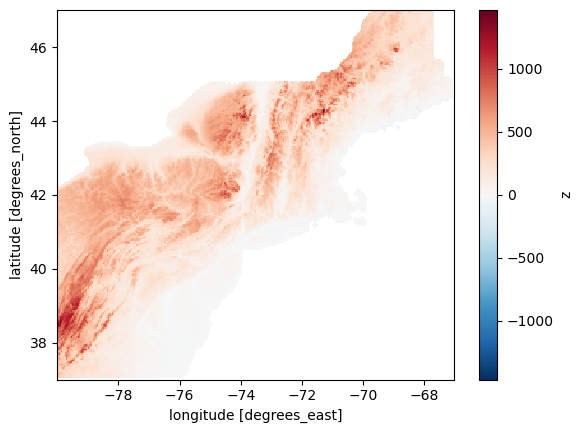

In [20]:
topo_on_gridmet_masked.plot()

In [21]:
# Save the masked topography as a standalone NetCDF file
save_path = "../.data/ETOPO2/topography_on_gridmet_masked.nc"
topo_on_gridmet_masked.to_netcdf(save_path)